In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Exercício 1

1. Gere uma amostra de tamanho $K$ de uma variável com distribuição binomial negativa com parâmetros $p$ $r$ utilizando os três métodos vistos em sala: via Bernoullis, via soma de geométricas, via recursão.
2. Compare com uma amostra gerada pelo numpy usando histogramas.
3. Compare o tempo dos três métodos como visto nos labs anteriores.



## 1.1.1 Via Bernoulli

In [7]:
r = 10
p = .5
K = 1000
def neg_bin_via_bern(r,p, K):
    bin_neg = []
    for _ in range(K):
        n = 0
        s = 0
        while s < r:
            U = np.random.uniform()
            n += 1
            s += U < p
        bin_neg.append(n)
    return bin_neg

## 1.1.2 Via soma de geométricas

In [8]:
def neg_bin_via_geo(r,p,K):
    unis = np.random.uniform(size = (K,r))
    geos = np.ceil(np.log(unis)/np.log(1-p))
    bin_neg = np.sum(geos, axis=1)
    return bin_neg

## 1.1.3 Via recursão

In [9]:
def neg_bin_via_rec(r,p,K):
    bin_neg = []
    for _ in range(K):
        U = np.random.uniform()
        n = r
        pi = p**r
        F = pi
        while U > F:
            pi = pi*n*(1-p)/(n-r+1)
            n += 1
            F += pi
        bin_neg.append(n)
    return bin_neg

## 1.2 Conclusões

In [10]:
bin_neg_bern = neg_bin_via_bern(r,p, K)
bin_neg_geo = neg_bin_via_geo(r,p,K)
bin_neg_rec = neg_bin_via_rec(r,p,K)

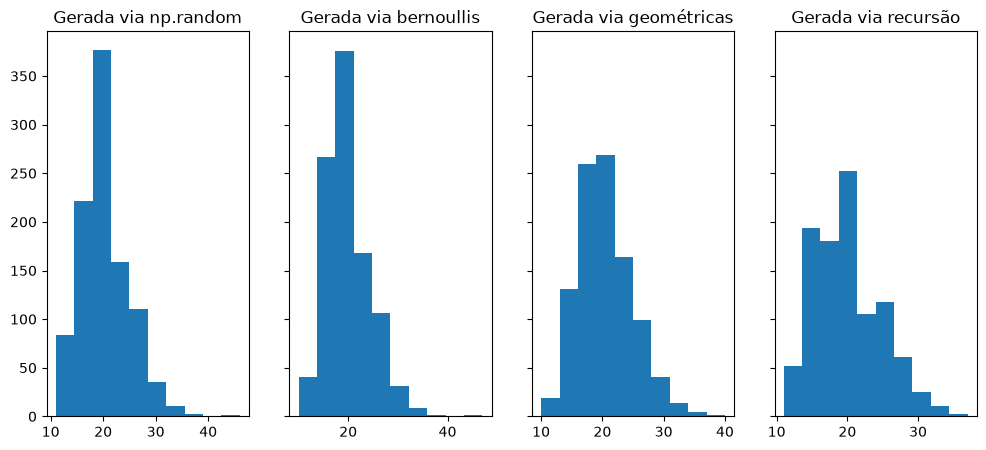

In [13]:
fig, ax = plt.subplots(1,4, figsize=(12,5), sharey=True)
ax[0].hist(np.random.negative_binomial(r,p,size = K) + r)
ax[0].set_title('Gerada via np.random')

ax[1].hist(bin_neg_bern)
ax[1].set_title('Gerada via bernoullis')
ax[2].hist(bin_neg_geo)
ax[2].set_title('Gerada via geométricas')
ax[3].hist(bin_neg_rec)
ax[3].set_title('Gerada via recursão')
plt.show()

In [14]:
# Médias
print(f'Média teórica: 20')
print(f'Média via bernoulli: {np.mean(bin_neg_bern)}')
print(f'Média via geométricas: {np.mean(bin_neg_geo)}')
print(f'Média via recursão: {np.mean(bin_neg_rec)}')
print(np.mean(np.random.negative_binomial(r,p, size =K))+r)

Média teórica: 20
Média via bernoulli: 19.951
Média via geométricas: 19.956
Média via recursão: 19.98
19.961


## 1.3

In [15]:
ps = np.linspace(0.05,0.9)
tempo_bernoullis = []
for p in ps:
    inicio = time.time()
    neg_bin_via_bern(r,p,K)
    tempo_bernoullis.append(time.time()-inicio)

In [16]:
tempo_geometricas=[]
for p in ps:
    inicio = time.time()
    neg_bin_via_geo(r,p,K)
    tempo_geometricas.append(time.time()-inicio)

In [17]:
tempo_recursao=[]
for p in ps:
    inicio = time.time()
    neg_bin_via_rec(r,p,K)
    tempo_recursao.append(time.time()-inicio)

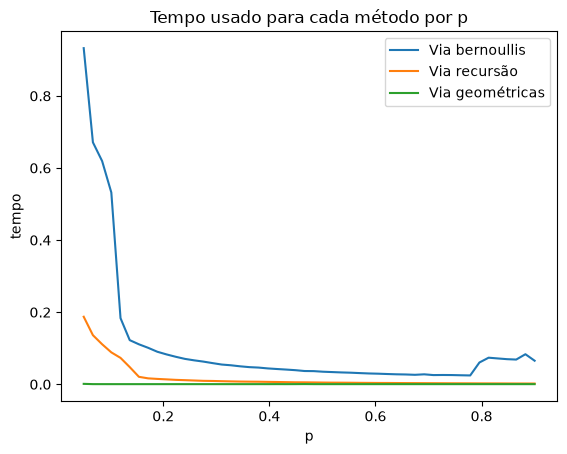

In [18]:
fig, ax = plt.subplots()
ax.plot(ps,tempo_bernoullis, label='Via bernoullis')
ax.plot(ps, tempo_recursao, label='Via recursão')
ax.plot(ps, tempo_geometricas, label='Via geométricas')
plt.xlabel('p')
plt.legend()
plt.ylabel('tempo')
plt.title('Tempo usado para cada método por p')
plt.show()

# Exercício 2

1.  Gere uma amostra de tamanho $K$ de uma variável aleatória com distribuição hipergeométrica com parâmetros $M,N,n$ utilizando o método de embaralhamento de Fisher–Yates.
2.  No método de Fisher-Yates, no passo (a), a gente amostra um ponto para troca entre $i$ e $N$. Pense em qual seria o problema caso a gente sempre amostrasse entre $1$ e $N$. Compare o resultado final usando essas duas versões e uma amostra gerada pelo numpy.

In [19]:
K = 10000

M = 2
N = 15
n = 3
def hipergeometrica(M,N,n,K):
    hipers =[]
    for _ in range(K):
        lista = [1] * M + [0] * (N)
        for i in range(n):
            u = np.random.uniform()
            pos = int(np.floor(((N+M)-i)*u + i))
            lista[i],lista[pos] = lista[pos], lista[i]
        hipers.append(np.sum(lista[:n]))
    return hipers
hipers = hipergeometrica(M,N,n,K)

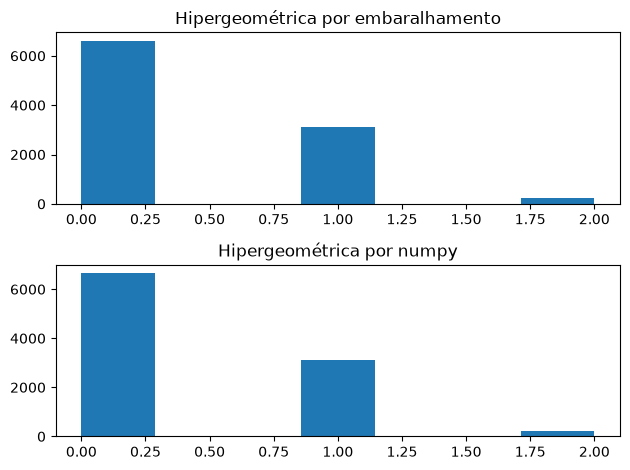

In [20]:
fig, ax = plt.subplots(2,1)
ax[0].hist(hipers, bins=7)
ax[0].set_title('Hipergeométrica por embaralhamento')
ax[1].hist(np.random.hypergeometric(M, N, n, size=K), bins=7)
ax[1].set_title('Hipergeométrica por numpy')
plt.tight_layout()
plt.show()

# Exercício 3

É intuitivo esperar que, quando o tamanho total da população $M+N$ cresce muito em relação ao tamanho da amostra $n$, o fato de a amostragem ser feita sem reposição passe a ter pouca importância, pois retirar um elemento altera muito pouco a composição da população restante. Nesse caso, cada retirada deve se comportar aproximadamente como um ensaio de Bernoulli independente, com probabilidade de sucesso

$$
p=\frac{N}{M+N}.
$$

Assim, esperamos que a distribuição hipergeométrica com parâmetros $M,N,n$ se aproxime de uma distribuição binomial com parâmetros $n$ e $p$.

Compare numericamente essas duas distribuições para valores crescentes de $M$ e $N$, mantendo aproximadamente constante a proporção

$$
\frac{N}{M+N}\to p,
$$

e mantendo $n$ fixo. Verifique, por meio de simulações, se a aproximação pela distribuição binomial melhora à medida que $M+N$ aumenta.


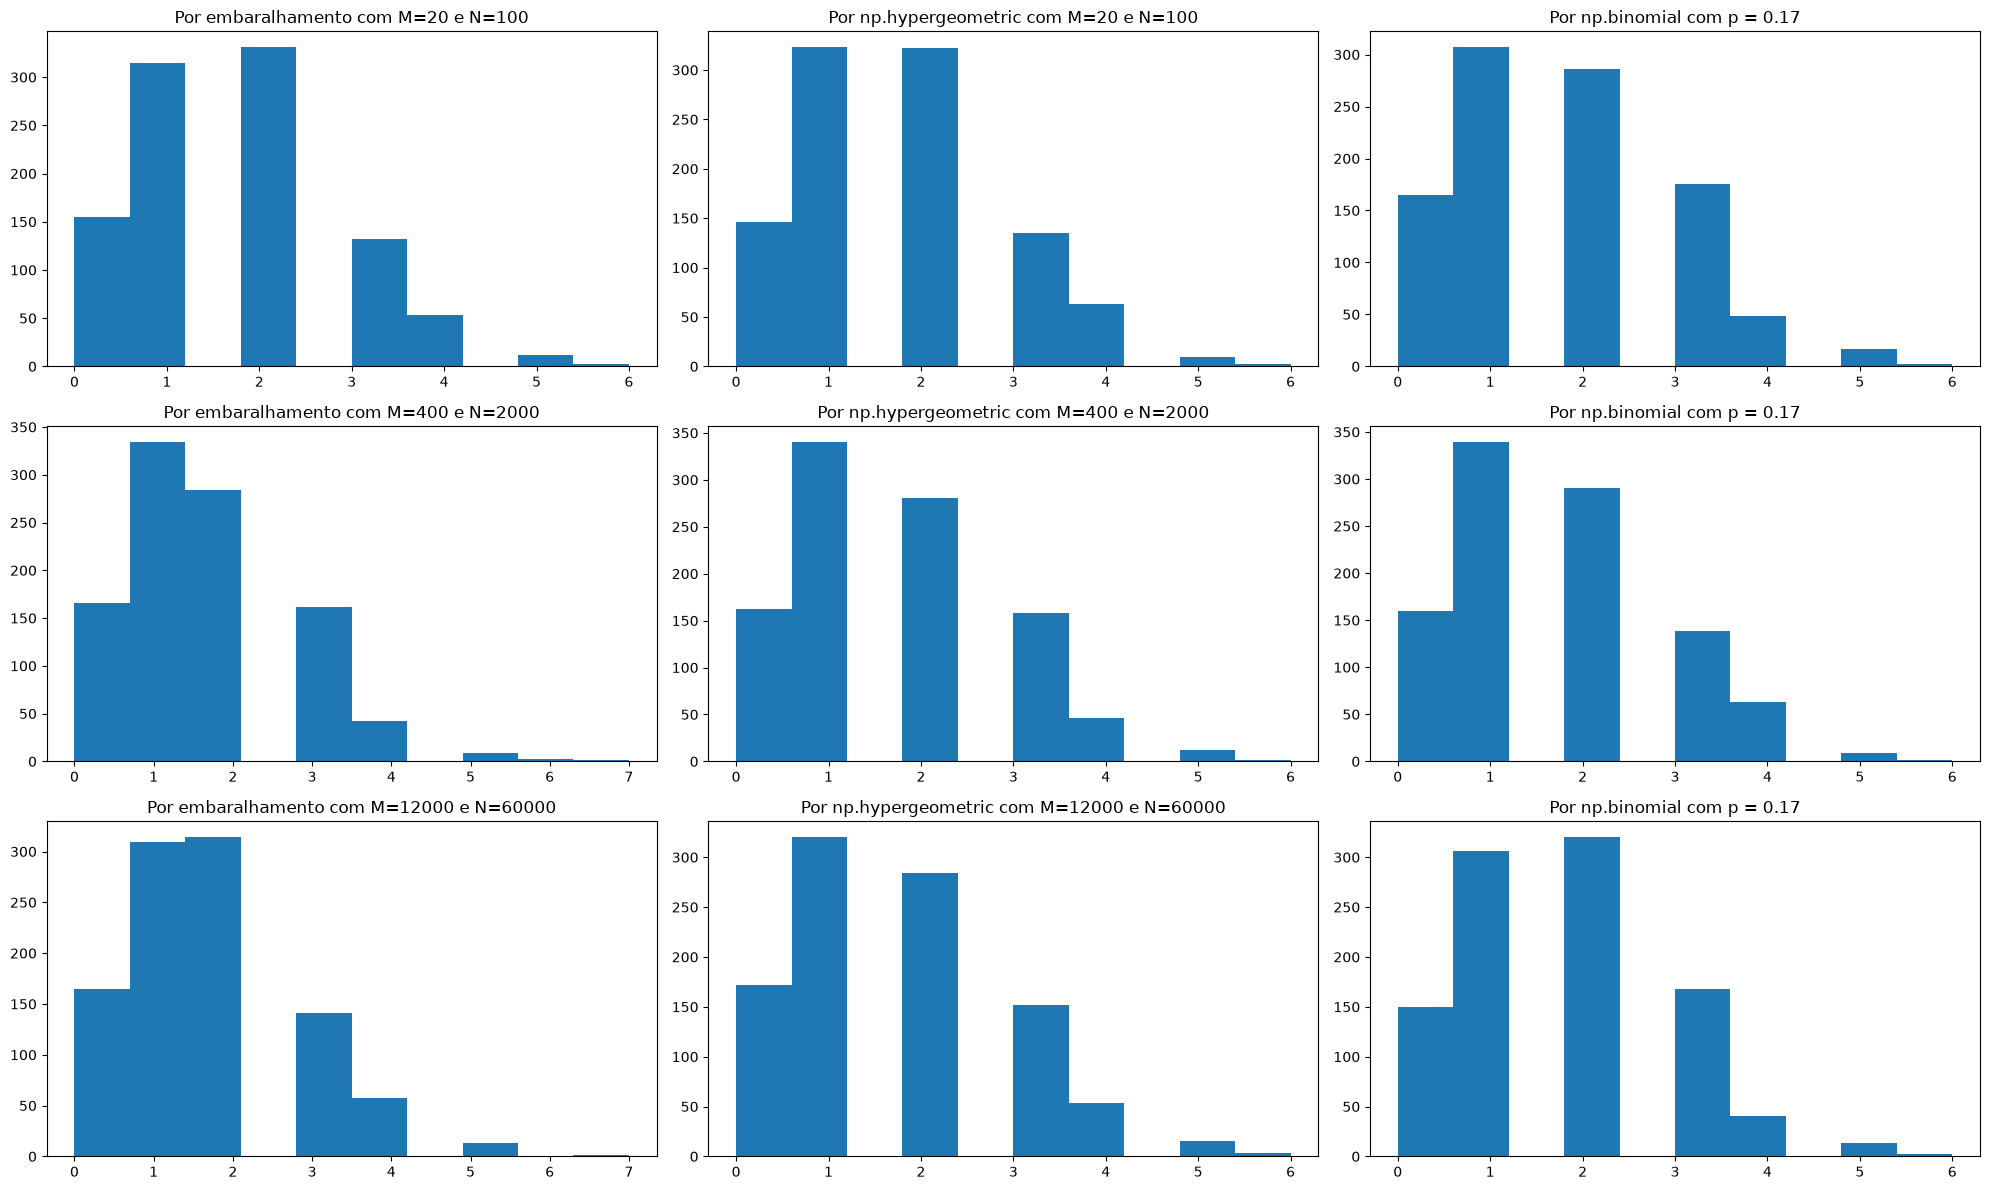

In [21]:
fig, ax = plt.subplots(3,3, figsize=(20,12))
N = 10
M = 2
n = 10
K = 1000
for i in range(3):
    M *= 10*(i+1)
    N *= 10*(i+1)
    hiper = hipergeometrica(M,N,n,K)
    ax[i][0].hist(hiper)
    ax[i][0].set_title(f'Por embaralhamento com M={M} e N={N}')
    ax[i][1].set_title(f'Por np.hypergeometric com M={M} e N={N}')
    ax[i][2].set_title(f'Por np.binomial com p = {M/(N+M):.2f}')
    ax[i][1].hist(np.random.hypergeometric(M,N,n, size=K))
    ax[i][2].hist(np.random.binomial(n, M/(M+N), size = K))
plt.tight_layout()

Nas últimas linhas, podemos ver que se assemelha muito mais do que nas iniciais